### Build a basic chatbot with Langgraph(GRAPH API)

#### COMPONENTS OF LANGGRAPH

- Edges
- Nodes
- State(Variables required ex. Transcript)


##### Solving workflows in Langgraph

- Graph API (Shows how your flow of execution will happen )
- Functional API

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages #(are called as reducers, appending the new added messages)

In [2]:
class State(TypedDict):
    # Messages have the yype "list". The add_message function in the annotations
    # defines how this state key should be updated(in this case,it appends messages to the list , rather than overwrting them)
    messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)

In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()


True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama-3.3-70b-versatile")

In [6]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002333BCFCC50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002333BDBDE10>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
#Another Way
llm=init_chat_model(model="groq:llama-3.3-70b-versatile")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002333BDDE910>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002333BDDF4D0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [8]:
##Node defination

def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [9]:
graph_builder=StateGraph(State)
#Adding nodes
graph_builder.add_node("llmchatbot",chatbot)
#Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

##Compile the graph
graph=graph_builder.compile()

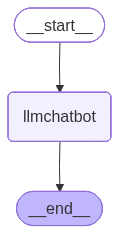

In [10]:
#Visualize the Graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [11]:
response=graph.invoke({"messages":"HI"})

In [12]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [13]:
for event in graph.stream({"messages":"How are you"}):
    for value in event.values():
        print(value)

{'messages': [AIMessage(content="I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you might have. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 38, 'total_tokens': 83, 'completion_time': 0.100782875, 'completion_tokens_details': None, 'prompt_time': 0.003201413, 'prompt_tokens_details': None, 'queue_time': 0.161628116, 'total_time': 0.103984288}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f168e-5de6-7162-ae15-f7ca9b7bbbae-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 38, 'output_tokens': 45, 'total_tokens': 83})]}


### Chatbot with tool

In [15]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph?")


{'query': 'What is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the 

In [30]:
##Custom Function

def multiply(a:int,b:int)->int:
    """Multiply a and b
    
    Args:
       a (int):first int
       b (int):second int
       
    Returns:
       int:_description_ 
       
       """
    return a*b

In [31]:
tools=[tool,multiply]

In [32]:
llm_with_tool=llm.bind_tools(tools)

In [34]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002333BDDE910>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002333BDDF4D0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search 

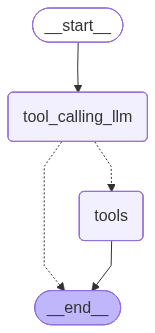

In [35]:
## StateGraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display


## Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Adding Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",  # <--- Changed from "tool_calling_condition" to match the node name
    # If the latest message(result) from the assistant is a tool call -> tools_condition routes to tools
    # If the latest message(result) from the assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

# compile the Graph
graph = builder.compile()


display(Image(graph.get_graph().draw_mermaid_png()))


In [36]:
response=graph.invoke({"messages":"What is the latest ai news"})

In [37]:
response

{'messages': [HumanMessage(content='What is the latest ai news', additional_kwargs={}, response_metadata={}, id='fc44d460-d956-4617-92d5-a40cf5b85c86'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '5r5kd3p2k', 'function': {'arguments': '{"query":"latest AI news","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1751, 'total_tokens': 1782, 'completion_time': 0.094804358, 'completion_tokens_details': None, 'prompt_time': 0.090221008, 'prompt_tokens_details': None, 'queue_time': 0.161523982, 'total_time': 0.185025366}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f16b8-3d18-78a1-9493-d69196ca9b81-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'latest AI news', 'time_range': 'day', 'topic': 'n

In [39]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the latest ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (5r5kd3p2k)
 Call ID: 5r5kd3p2k
  Args:
    query: latest AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://time.com/article/2026/06/29/recursive-self-improvement-is-the-human-skill-we-need-in-the-ai-age/", "title": "Recursive Self-Improvement is the Human Skill We Need in the AI Age - Time Magazine", "score": 0.7187726, "published_date": "Mon, 29 Jun 2026 19:00:03 GMT", "content": "# Recursive Self-Improvement is the Human Skill We Need in the AI Age. The news is full of sober warnings about AI. The latest: recursive self-improvement, or RSI. RSI is the process b

In [43]:
response=graph.invoke({"messages":"8*7"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

8*7
================================== Ai Message ==================================
Tool Calls:
  multiply (ypef7xsc4)
 Call ID: ypef7xsc4
  Args:
    a: 8
    b: 7
================================= Tool Message =================================
Name: multiply

56


## ReAct Agent
3 main components

- Act
- Observe
- Reason 

What React Agent does is :

## input->llm ->toolNode -> llm->end


## Normally 
##         ^--------------->
##         |               |   
## input->llm->toolNode-> end
        


### React Agent Architecture

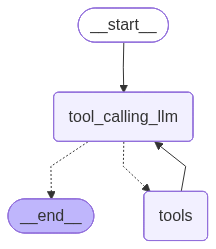

In [44]:
## StateGraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display


## Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Adding Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",  # <--- Changed from "tool_calling_condition" to match the node name
    # If the latest message(result) from the assistant is a tool call -> tools_condition routes to tools
    # If the latest message(result) from the assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm",END)

# compile the Graph
graph = builder.compile()


display(Image(graph.get_graph().draw_mermaid_png()))


In [45]:
response=graph.invoke({"messages":"what is the latest ai news and 7*9"})
for m in response["messages"]:
    m.pretty_print()


================================ Human Message =================================

what is the latest ai news and 7*9
================================== Ai Message ==================================
Tool Calls:
  tavily_search (aa34ethwc)
 Call ID: aa34ethwc
  Args:
    query: latest AI news
    time_range: day
    topic: news
  multiply (46vw4gw11)
 Call ID: 46vw4gw11
  Args:
    a: 7
    b: 9
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://time.com/article/2026/06/29/recursive-self-improvement-is-the-human-skill-we-need-in-the-ai-age/", "title": "Recursive Self-Improvement is the Human Skill We Need in the AI Age - Time Magazine", "score": 0.7187726, "published_date": "Mon, 29 Jun 2026 19:00:03 GMT", "content": "# Recursive Self-Improvement is the Human Skill We Need in the AI Age. The news is full of sober warnings a

## Adding memory to Chatbot

In [46]:
response=graph.invoke({"messages":"Hi my name is Yash Raut "})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi my name is Yash Raut 
================================== Ai Message ==================================

Hello Yash Raut! It's nice to meet you. Is there something I can help you with or would you like to chat?


In [47]:
response=graph.invoke({"messages":"What is my Name "})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my Name 
================================== Ai Message ==================================

I don't have any information about your name. If you'd like to share it with me, I can try to help you with anything else you might need.


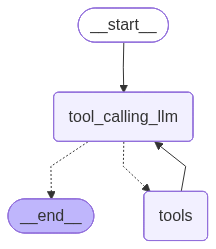

In [50]:
## StateGraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()


## Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Adding Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",  # <--- Changed from "tool_calling_condition" to match the node name
    # If the latest message(result) from the assistant is a tool call -> tools_condition routes to tools
    # If the latest message(result) from the assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm",END)

# compile the Graph
graph = builder.compile(checkpointer=memory)


display(Image(graph.get_graph().draw_mermaid_png()))


In [51]:
##Create a thread Id

config={"configurable":{"thread_id":"user"}}

response=graph.invoke({"messages":"Hello My name is Yash"},config=config)

In [53]:

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello My name is Yash
================================== Ai Message ==================================

Hello Yash! It's nice to meet you. Is there something I can help you with or would you like to chat?


In [54]:
response=graph.invoke({"messages":"Hey! What is my name"},config=config)
print(response["messages"][-1])

content='Your name is Yash.' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 1793, 'total_tokens': 1800, 'completion_time': 0.006973109, 'completion_tokens_details': None, 'prompt_time': 0.093042253, 'prompt_tokens_details': None, 'queue_time': 0.052837117, 'total_time': 0.100015362}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019f16d3-1abe-72d1-8ef1-79de928c1034-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 1793, 'output_tokens': 7, 'total_tokens': 1800}


## STREAMING